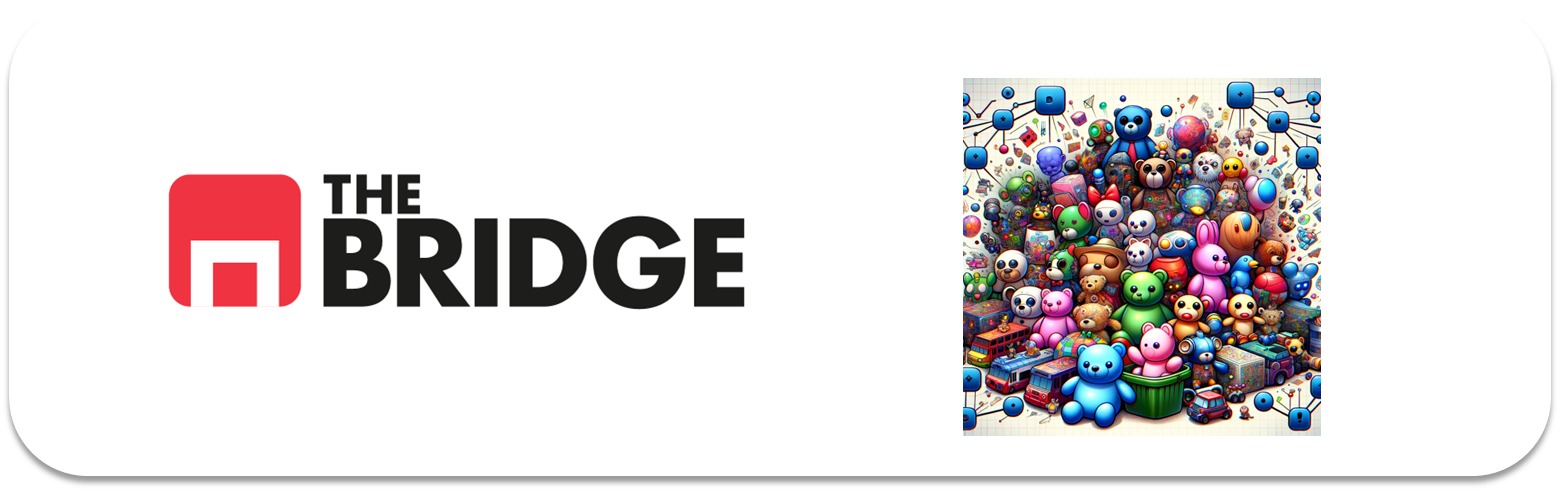

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from bootcampviztools import *

In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score



### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [3]:
df_ed=pd.read_csv("./data/empowering_drinks.csv", sep="|")
df_ne=pd.read_csv("./data/new_experiments.csv", sep="|")
df_pr=pd.read_csv("./data/power_results.csv", sep="|")

In [4]:
display(df_pr)
print(df_pr.value_counts())

,class
0,1
1,1
2,1
3,1
4,1
...,...
154,1
155,2
156,2
157,3


class
2        62
1        58
3        39
Name: count, dtype: int64


In [5]:
display(df_ed)
df_ed.info()
df_ed.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
...,...,...,...,...,...
148,0.493343,0.414820,-1.284344,0.009893,0.969783
149,0.332758,-0.389355,-1.344582,0.280575,2.224236
150,0.209232,0.012732,-1.354622,0.296498,1.834923
151,1.395086,1.365208,-1.274305,-0.595160,1.791666


<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [6]:
display(df_ne)
df_ne.info()
df_ne.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               6 non-null      float64
 1   Vitamínas del grupo B  6 non-null      float64
 2   Cafeína                6 non-null      float64
 3   Ácido Cítrico          6 non-null      float64
 4   Taurina                6 non-null      float64
dtypes: float64(5)
memory usage: 372.0 bytes


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,0.028059,0.085839,-0.348982,0.106490,-0.032337
std,1.205271,0.826463,1.139233,1.157346,1.143657
min,-1.680724,-1.412851,-1.565455,-1.193845,-0.976782
25%,-0.766628,-0.106066,-1.211557,-0.368265,-0.704263
50%,0.165997,0.323436,-0.561488,-0.149331,-0.593957
75%,0.876275,0.561033,0.352122,0.212905,0.418256
max,1.481555,0.890014,1.366128,2.239039,1.956043


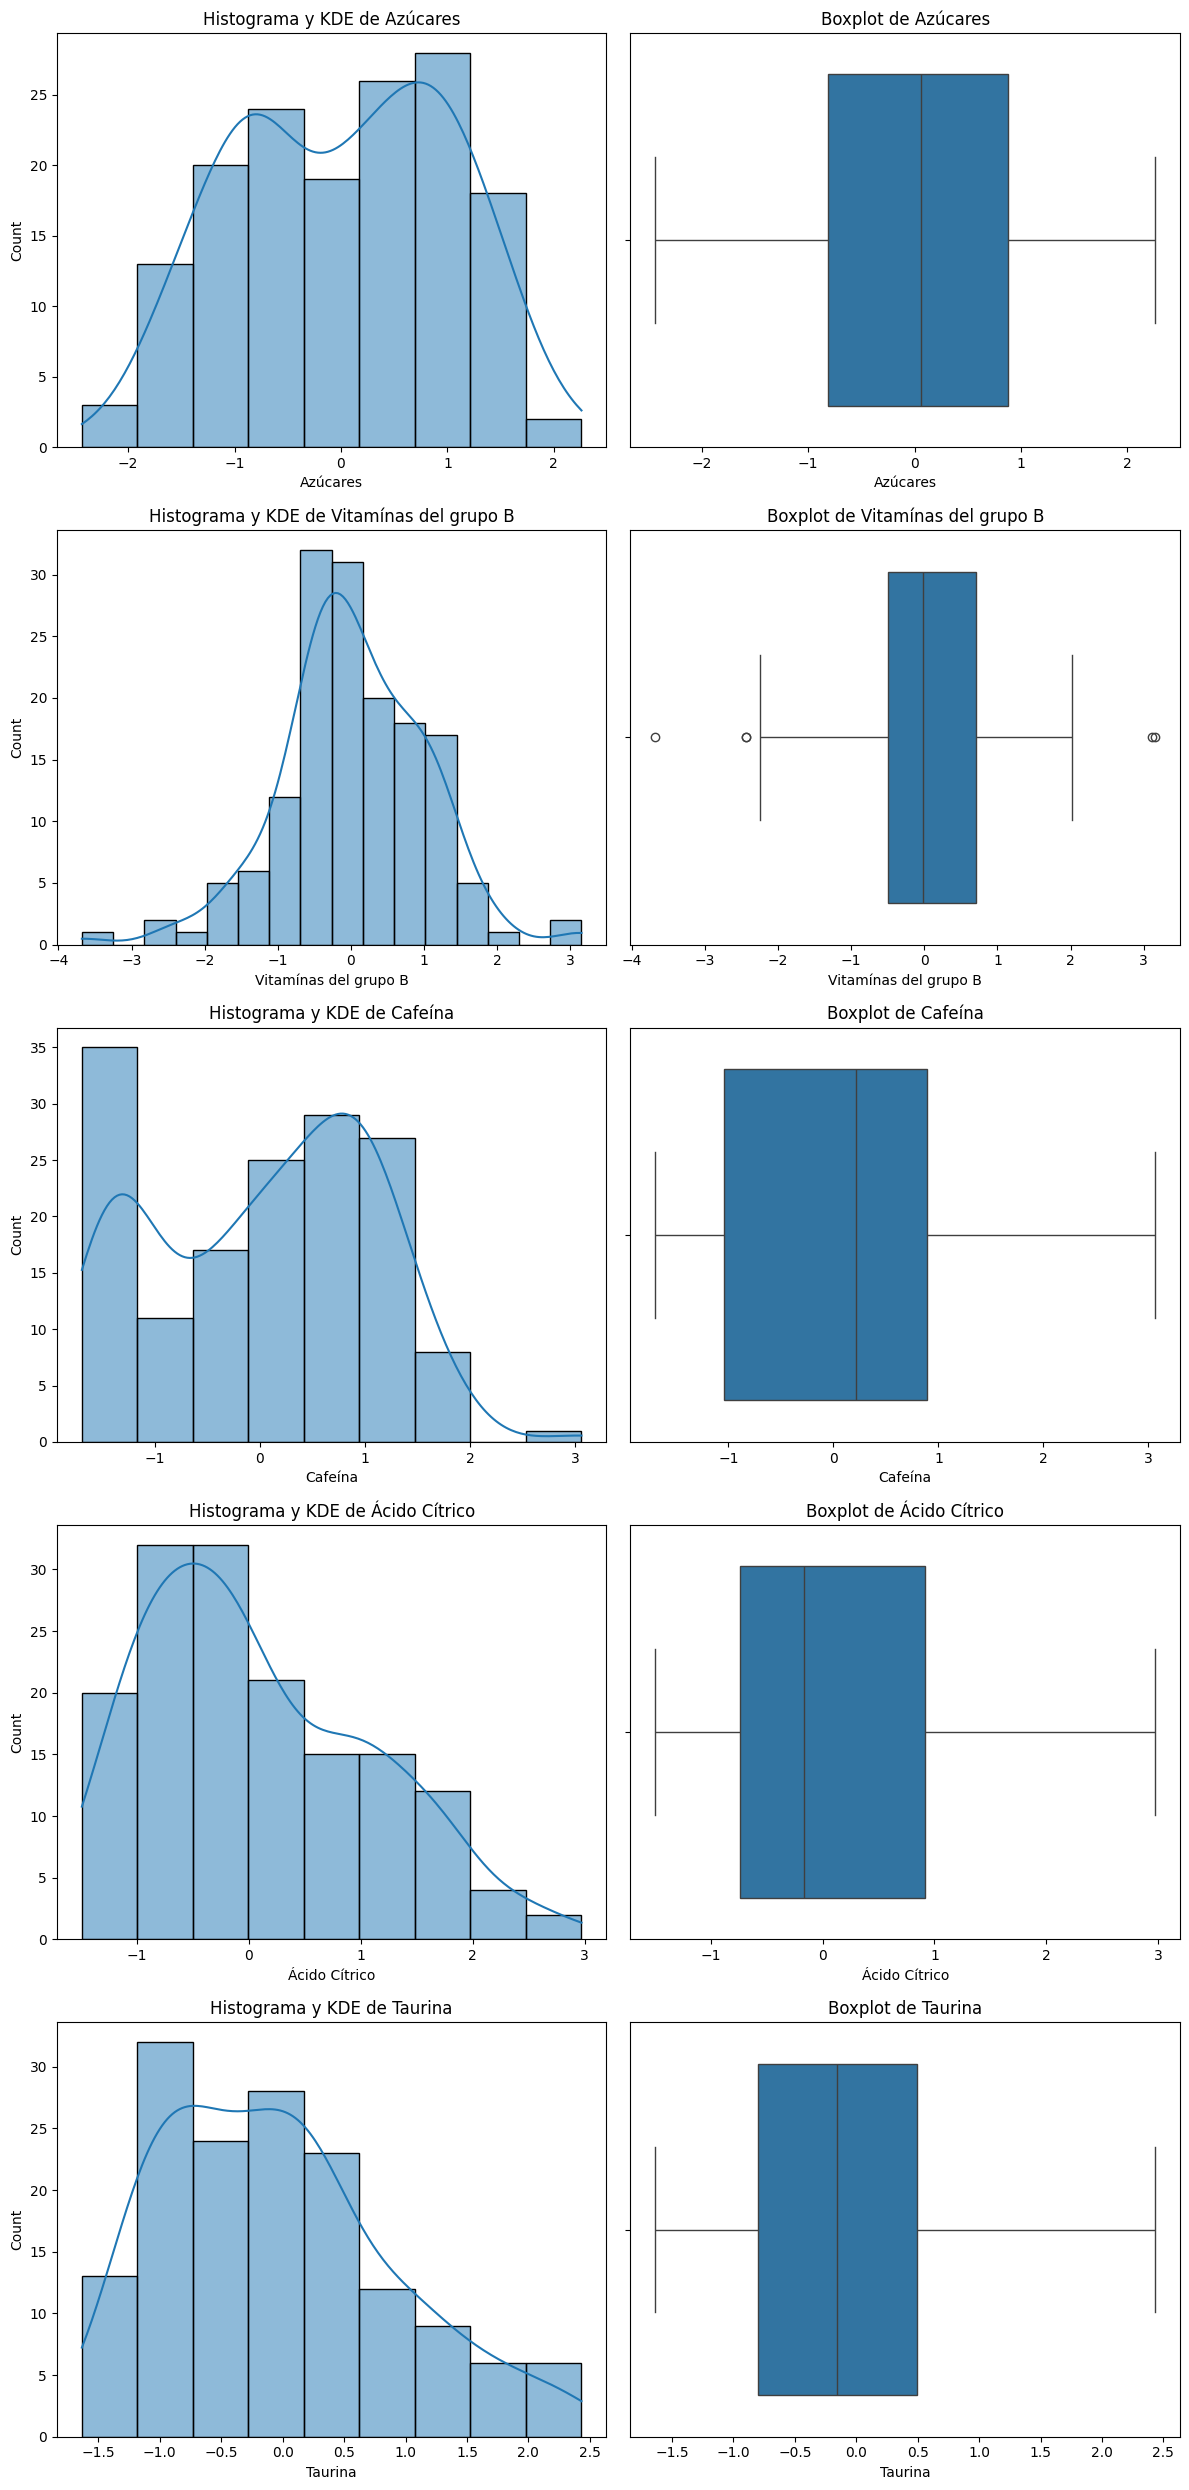

In [7]:
plot_combined_graphs(df_ed, df_ed.columns.to_list())

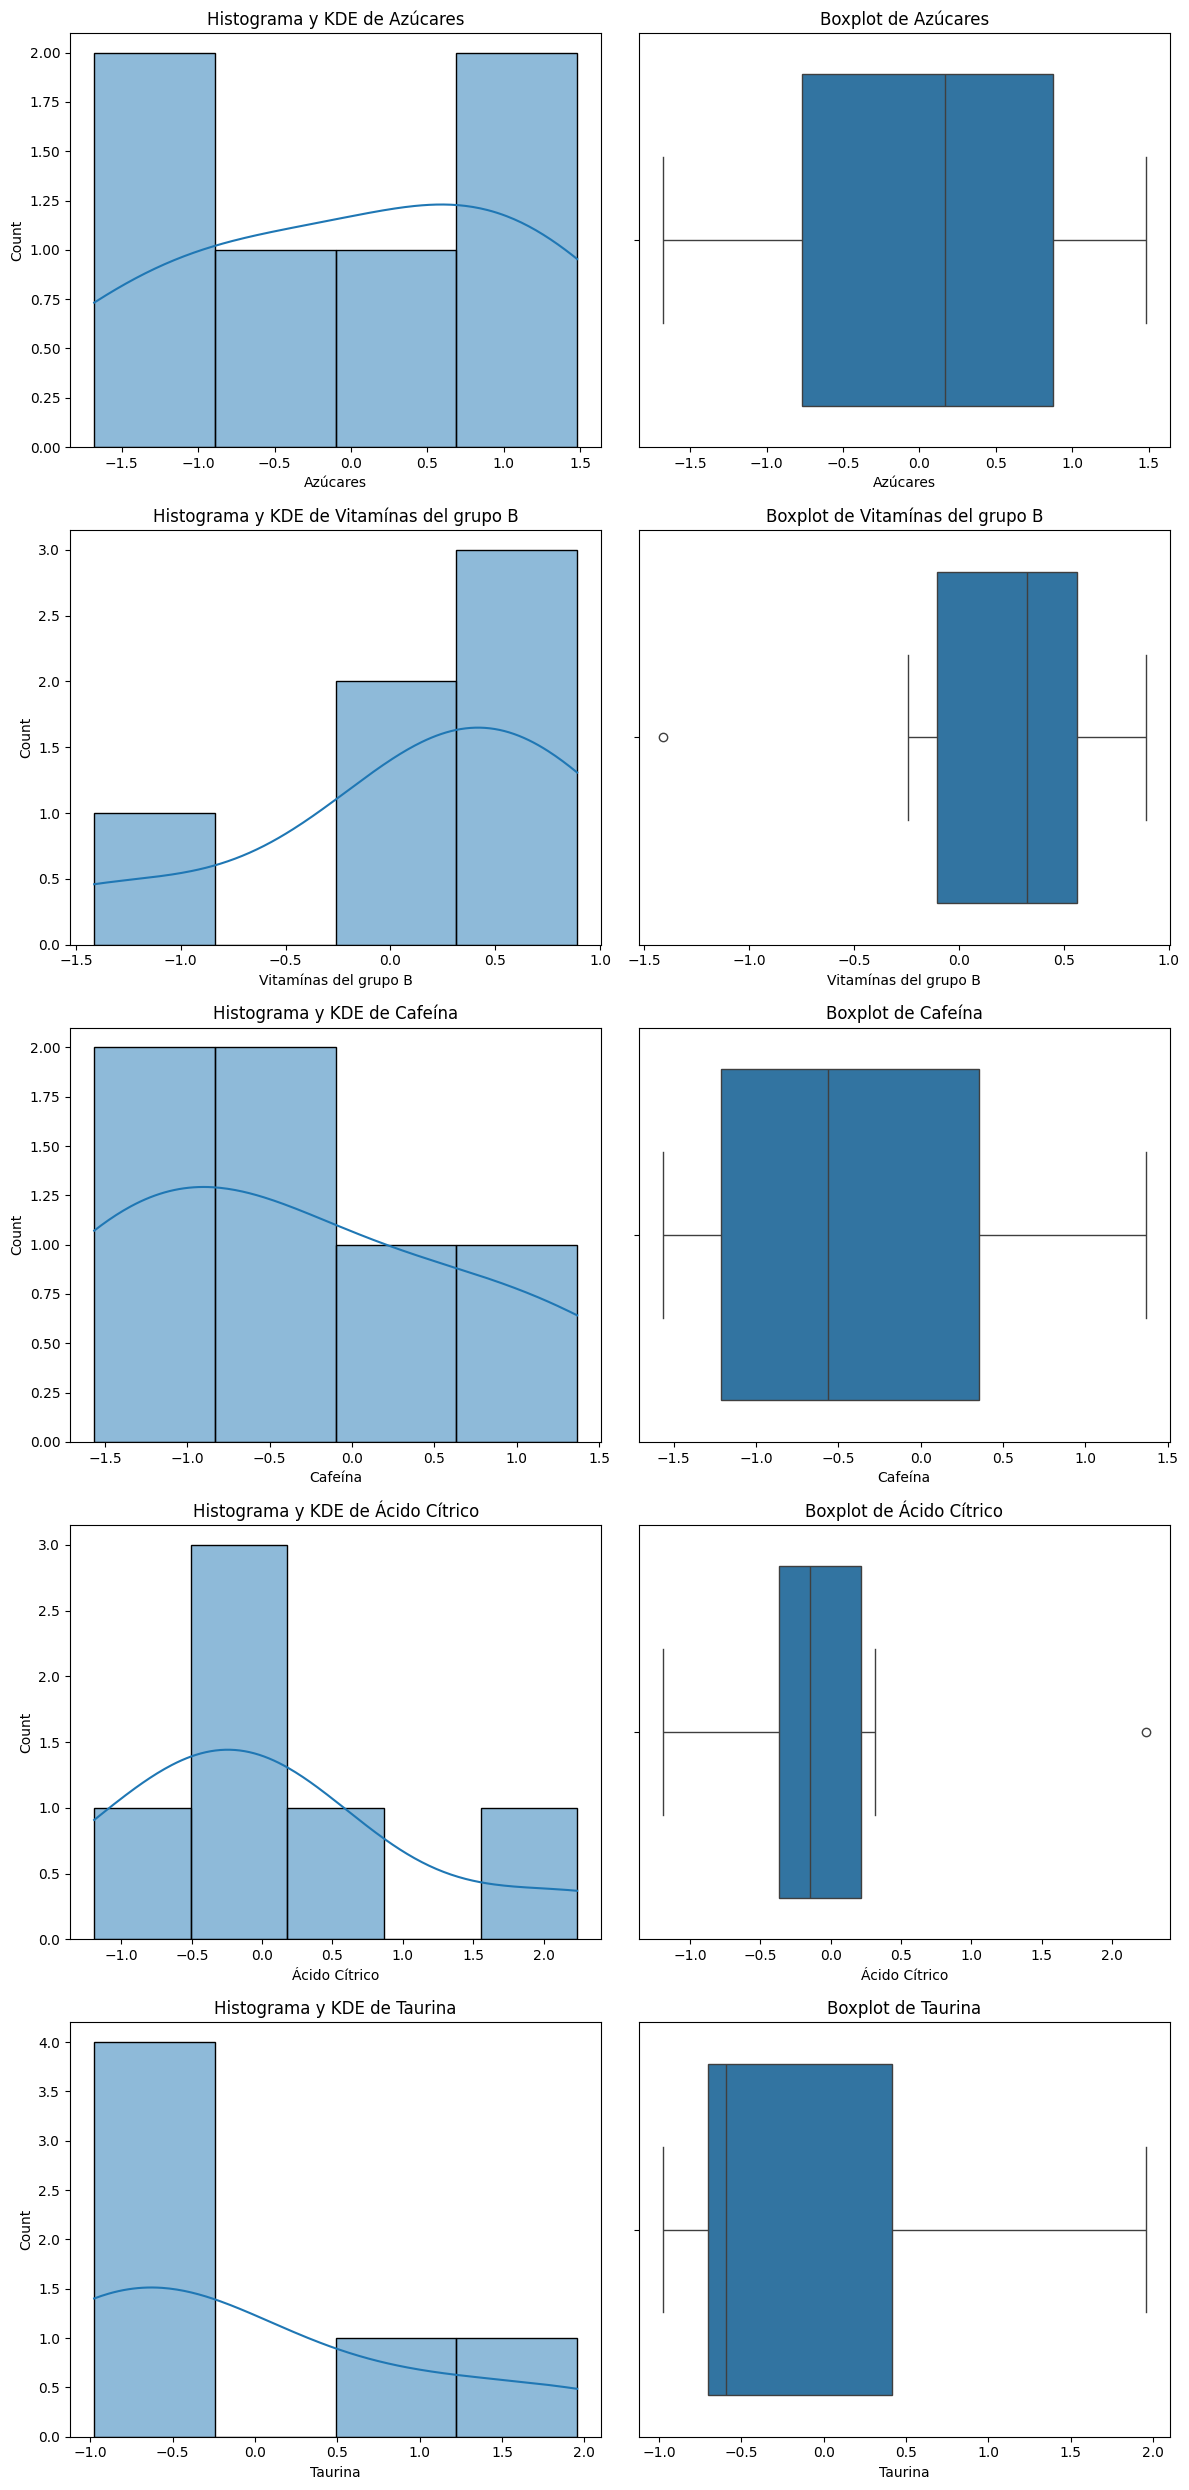

In [8]:
plot_combined_graphs(df_ne, df_ne.columns.to_list())

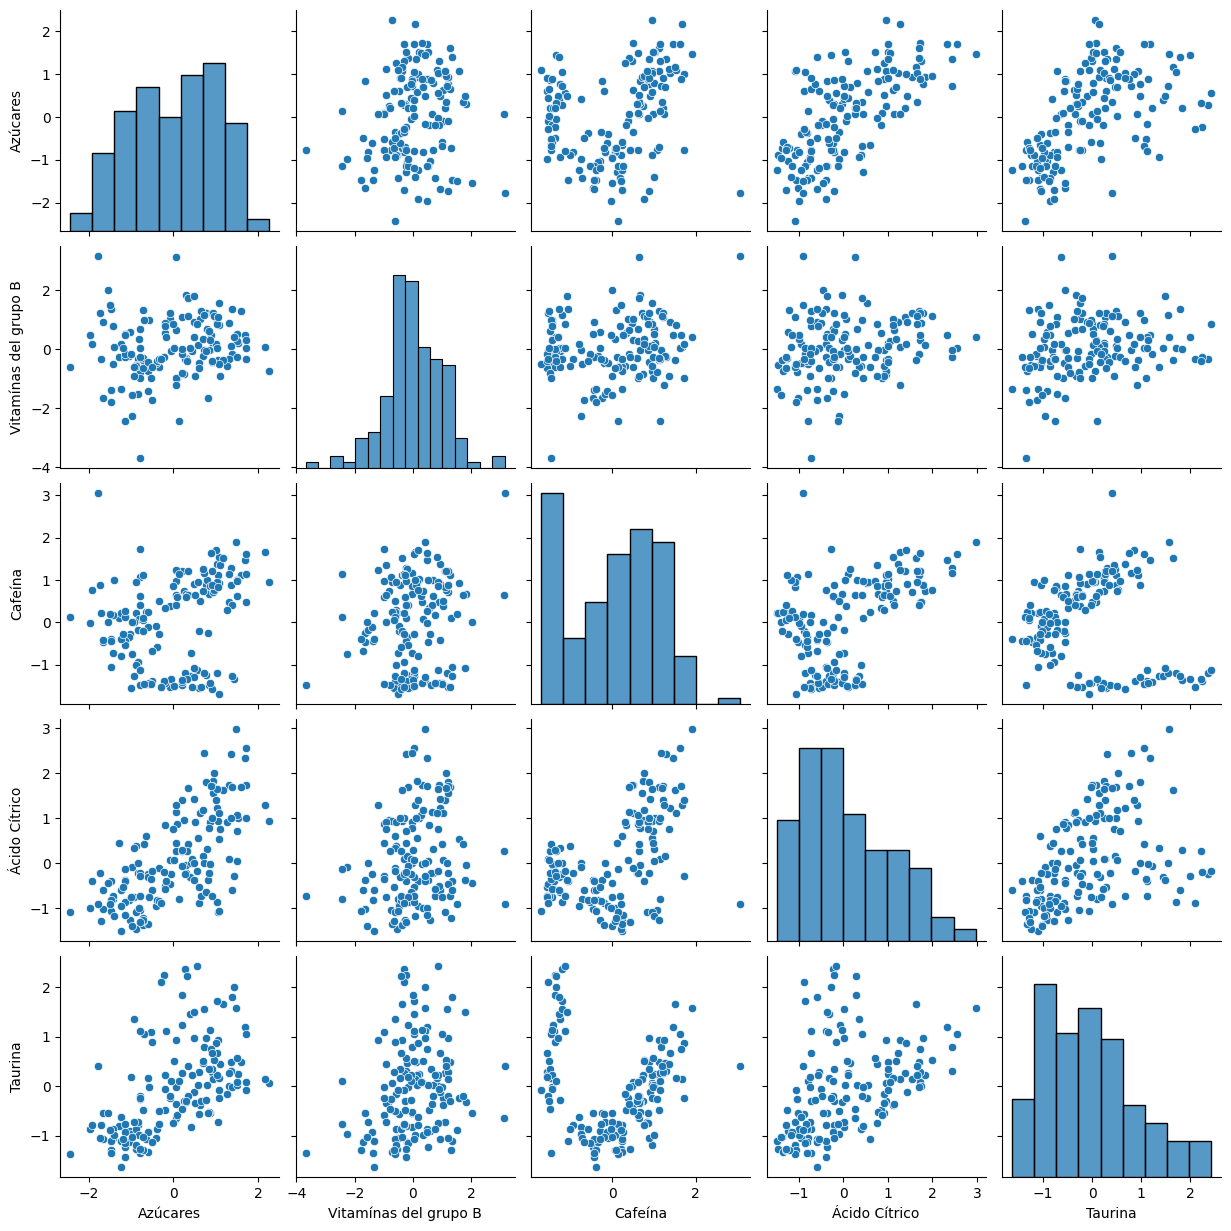

In [9]:
sns.pairplot(df_ed)

In [10]:
features = ['Azúcares', 'Cafeína', 'Ácido Cítrico', 'Taurina']
X = df_ed[features].values

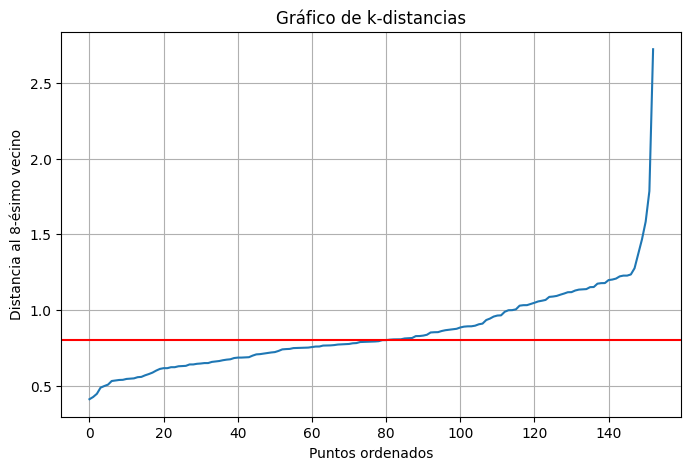

In [11]:
min_samples = 8  # ~2 x n_features, punto de partida

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X)
distancias, _ = nn.kneighbors(X)
k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distancias)
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino')
plt.xlabel('Puntos ordenados')
plt.title('Gráfico de k-distancias')
plt.axhline(y =0.8, color = 'r', linestyle = '-')
plt.grid(True)
plt.show()

In [29]:
for eps in [0.7, 0.8, 0.9, 1.0, 1.1, 1,2]:
    dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
    labels_temp = dbscan_temp.fit_predict(X)
    n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
    n_noise = list(labels_temp).count(-1)
    print(f'eps={eps}: clusters={n_clusters}, ruido={n_noise}')

eps=0.7: clusters=2, ruido=66
eps=0.8: clusters=3, ruido=30
eps=0.9: clusters=2, ruido=15
eps=1.0: clusters=2, ruido=6
eps=1.1: clusters=1, ruido=4
eps=1: clusters=2, ruido=6
eps=2: clusters=1, ruido=0


In [13]:
eps = 0.8

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X)

df_ed['cluster_dbscan'] = labels_dbscan
print(pd.Series(labels_dbscan).value_counts())

 0    55
 1    44
-1    30
 2    24
Name: count, dtype: int64


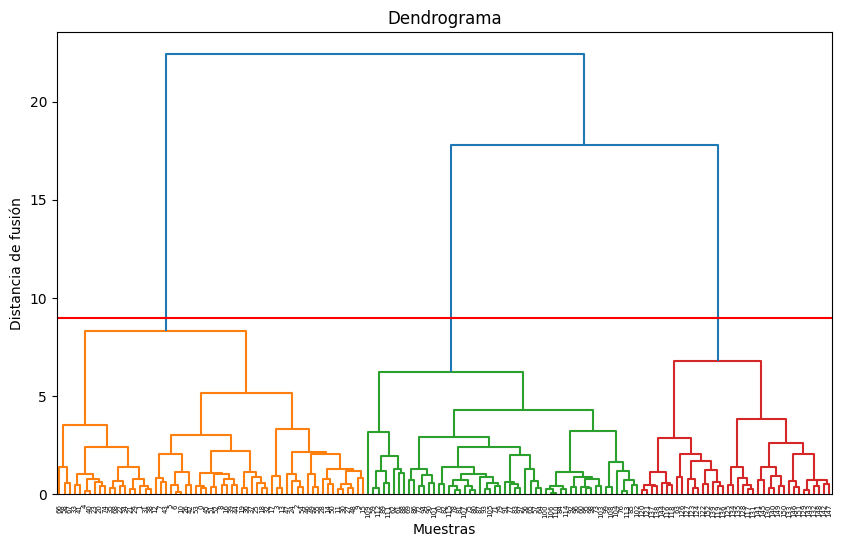

In [14]:
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma')
plt.xlabel('Muestras')
plt.ylabel('Distancia de fusión')
plt.axhline(y = 9, color = 'r', linestyle = '-')
plt.show()

In [15]:
from scipy.cluster.hierarchy import fcluster

for h in [6, 8, 10, 12, 15, 18, 20]:
    labels_h = fcluster(Z, t=h, criterion='distance')
    print(f'altura={h}: n_clusters={len(set(labels_h))}')

altura=6: n_clusters=6
altura=8: n_clusters=4
altura=10: n_clusters=3
altura=12: n_clusters=3
altura=15: n_clusters=3
altura=18: n_clusters=2
altura=20: n_clusters=2


In [16]:
n_clusters = 3
agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_agglo = agglo.fit_predict(X)

df_ed['cluster_agglo'] = labels_agglo
print(pd.Series(labels_agglo).value_counts())

0    61
2    54
1    38
Name: count, dtype: int64


In [17]:
# DBSCAN
eps = 0.8
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X)
df_ed['cluster_dbscan'] = labels_dbscan

# Jerárquico
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agglo = agglo.fit_predict(X)
df_ed['cluster_agglo'] = labels_agglo

In [18]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print(f'Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.2%}')

Varianza explicada por las 2 componentes: 85.00%


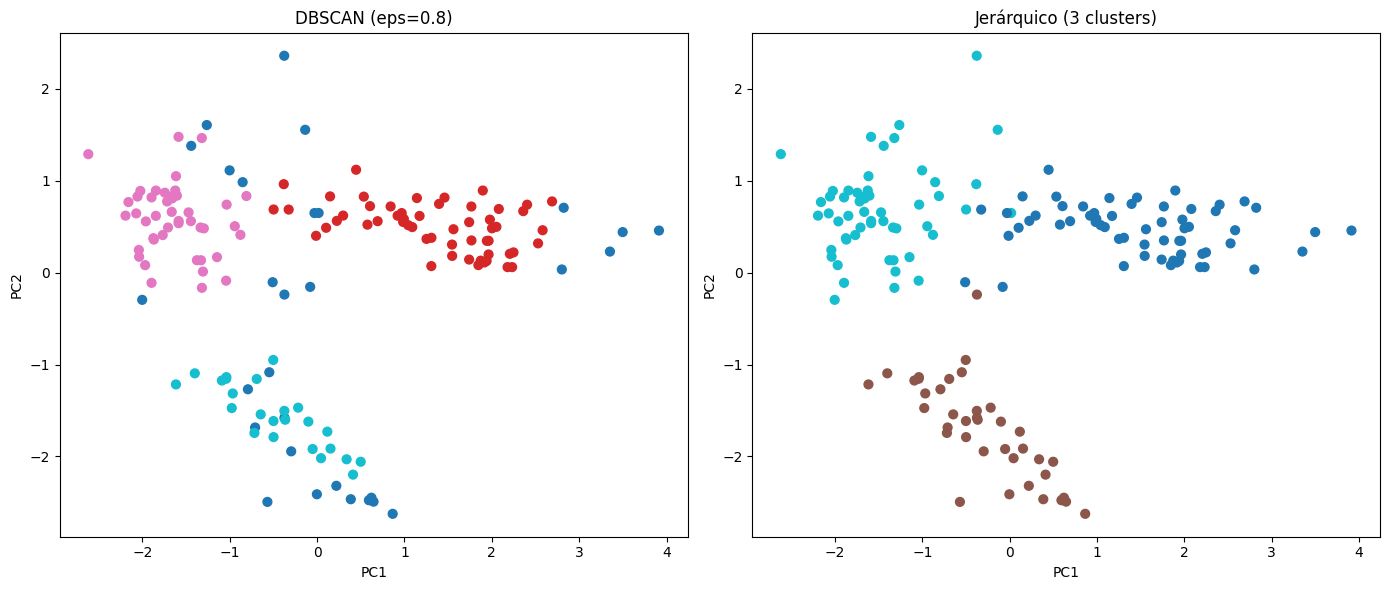

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DBSCAN: el -1 (ruido) lo resaltamos en gris para distinguirlo de un cluster real
scatter0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_dbscan, cmap='tab10', s=40)
axes[0].set_title(f'DBSCAN (eps={eps})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

scatter1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_agglo, cmap='tab10', s=40)
axes[1].set_title('Jerárquico (3 clusters)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [20]:
print('Silhouette DBSCAN (sin ruido):',
      silhouette_score(X[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]))
print('Silhouette Jerárquico:', silhouette_score(X, labels_agglo))

Silhouette DBSCAN (sin ruido): 0.5260391109811324
Silhouette Jerárquico: 0.4742202395817837


In [21]:
print(pd.Series(labels_dbscan).value_counts())

 0    55
 1    44
-1    30
 2    24
Name: count, dtype: int64


* Comparación cuantitativa. DBSCAN obtuvo un silhouette de 0.526 (excluyendo el ruido) frente a 0.474 del jerárquico. La diferencia es modesta y no debe interpretarse como "DBSCAN es mejor": DBSCAN calculó su métrica sobre un subconjunto más fácil, al dejar fuera los ~30 puntos de frontera que el jerárquico sí tuvo que asignar a un grupo. Ambos valores, en cualquier caso, indican una separación moderada-buena entre los 3 segmentos (silhouette > 0.4-0.5 se considera una estructura razonable, aunque no perfecta).
* Comparación cualitativa. Ambos modelos coinciden en identificar la misma estructura espacial de 3 grupos en la proyección PCA, lo cual refuerza la confianza en que esos 3 segmentos son reales y no un artefacto de un único algoritmo. La diferencia principal está en los puntos de ruido de DBSCAN: no se concentran en una sola zona, sino que aparecen repartidos en los bordes de los tres grupos — es decir, representan mezclas "frontera" más que un cuarto segmento independiente.
* ¿Por qué esta comparación es especulativa? Porque en este punto del análisis no contamos con el dato real de energización de cada mezcla — el silhouette y la inspección visual solo evalúan qué tan compactos y separados están los grupos según las propias variables de entrada, no si esos grupos corresponden a niveles reales de energización. Es una validación interna, no una validación contra la realidad.
* Mecanismo de mejora propuesto. Sería valioso revisar específicamente los ~30 puntos que DBSCAN marca como ruido: ¿son mezclas genuinamente atípicas, o simplemente caen justo en el límite de densidad entre dos grupos vecinos? Una opción sería pedir a los químicos una validación cualitativa de una muestra de esos puntos frontera, para decidir si deberían reasignarse a su grupo más cercano o si realmente representan una categoría aparte.

### Parte II. Nuevos experimentos

       Azúcares   Cafeína  Ácido Cítrico   Taurina
count  6.000000  6.000000       6.000000  6.000000
mean   0.028059 -0.348982       0.106490 -0.032337
std    1.205271  1.139233       1.157346  1.143657
min   -1.680724 -1.565455      -1.193845 -0.976782
25%   -0.766628 -1.211557      -0.368265 -0.704263
50%    0.165997 -0.561488      -0.149331 -0.593957
75%    0.876275  0.352122       0.212905  0.418256
max    1.481555  1.366128       2.239039  1.956043
   cluster_asignado
0                 0
1                 0
2                 2
3                 2
4                 2
5                 1


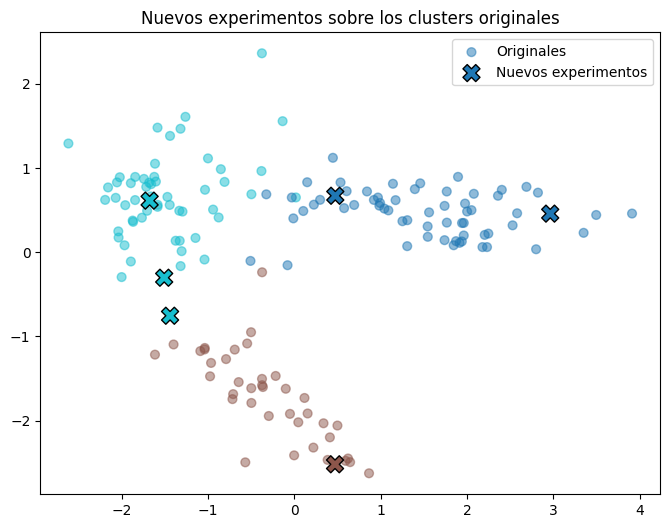

In [22]:

new_df = pd.read_csv('./data/new_experiments.csv', sep='|')
print(new_df[features].describe())  # confirmar que está en la misma escala

X_new = new_df[features].values

# Pseudo-target: usamos las etiquetas del jerárquico (sin clase "ruido")
clasificador = KNeighborsClassifier(n_neighbors=5)
clasificador.fit(X, labels_agglo)
nuevas_etiquetas = clasificador.predict(X_new)
new_df['cluster_asignado'] = nuevas_etiquetas
print(new_df[['cluster_asignado']])

# Verificación visual: proyectamos los nuevos puntos con el MISMO pca ya entrenado
X_new_2d = pca.transform(X_new)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_agglo, cmap='tab10', s=40, alpha=0.5, label='Originales')
plt.scatter(X_new_2d[:, 0], X_new_2d[:, 1], c=nuevas_etiquetas, cmap='tab10', s=150,
            marker='X', edgecolor='black', label='Nuevos experimentos')
plt.legend()
plt.title('Nuevos experimentos sobre los clusters originales')
plt.show()

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

Version Kmeans


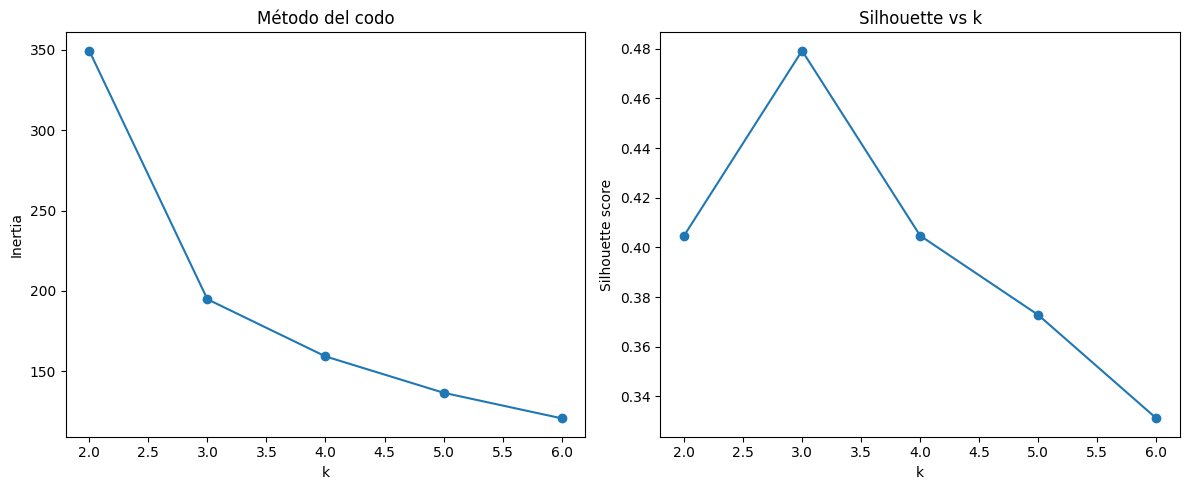

In [23]:
from sklearn.cluster import KMeans

inertias = []
silhouettes = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o')
axes[1].set_title('Silhouette vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

In [24]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
df_ed['cluster_kmeans'] = labels_kmeans
print(pd.Series(labels_kmeans).value_counts())

silhouette_kmeans = silhouette_score(X, labels_kmeans)
print('Silhouette K-Means:', silhouette_kmeans)

2    63
1    53
0    37
Name: count, dtype: int64
Silhouette K-Means: 0.47925070971738065


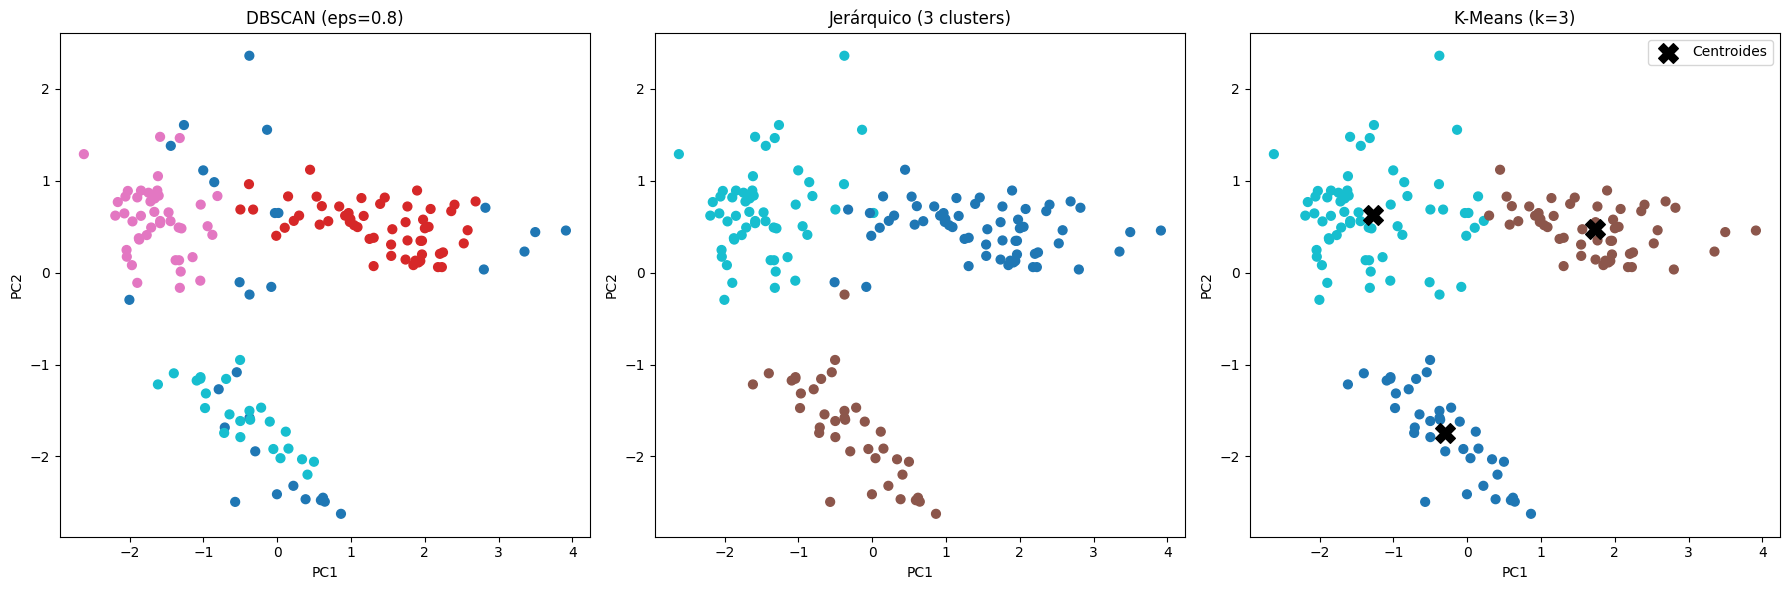

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_dbscan, cmap='tab10', s=40)
axes[0].set_title(f'DBSCAN (eps={eps})')

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_agglo, cmap='tab10', s=40)
axes[1].set_title('Jerárquico (3 clusters)')

axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='tab10', s=40)
# Centroides en el espacio de PCA, solo para visualizar
centroides_2d = pca.transform(kmeans.cluster_centers_)
axes[2].scatter(centroides_2d[:, 0], centroides_2d[:, 1], c='black', marker='X', s=200, label='Centroides')
axes[2].set_title('K-Means (k=3)')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import adjusted_rand_score

ari_kmeans_agglo = adjusted_rand_score(labels_kmeans, labels_agglo)
print('ARI K-Means vs Jerárquico:', ari_kmeans_agglo)

print(pd.crosstab(labels_kmeans, labels_agglo))

ARI K-Means vs Jerárquico: 0.8176031217747189
col_0   0   1   2
row_0            
0       0  37   0
1      53   0   0
2       8   1  54


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.